In [1]:
import ibis as ibis
import pandas as pd
import polars as pl
from mountainash_data import BaseDataFrame, DataFrameFactory, DataFrameUtils, IbisDataFrame
import ibis.expr.types as ir
from ibis import _

# from ibis.expr.visualize import to_graph

# ibis.set_backend(backend='polars')
ibis.options.sql.default_limit = None

In [4]:
df = pd.DataFrame(
    [["a", 1, 2], ["b", 3, 4]],
    columns=["one", "two", "three"],
    index=[5, 6],
)
df

df2 = pd.DataFrame(
    [["a", 1, 2, 3], ["b", 3, 4, 5], ["c", 3, 4, 5]],
    columns=["one", "two", "three", "four"]
)
df2

# df_pq = pl.scan_parquet("/Users/nathanielramm/data/mountainash/MountainAsh/PL/20240101/report/report_data/REPORT_DATA_ACCOUNTHOLDERS_B0001.parquet")
df_pq = pl.read_parquet("/Users/nathanielramm/data/mountainash/MountainAsh/PL/20240101/report/report_data/REPORT_DATA_ACCOUNTS_B0001.parquet")


obj_pd_pq: BaseDataFrame = IbisDataFrame(df=df_pq)
# obj_pd_pq: BaseDataFrame = DataFrameFactory.create_ibis_dataframe_object(df=df_pq)
# obj_pd_pq.df.explain()
type(obj_pd_pq)

ParserException: Parser Error: syntax error at or near "NULL"

In [7]:
obj_pd_pq.ibis_backend.name
obj_pd_pq.ibis_backend.list_tables()

['dea42599-6907-4281-b6d1-d721b9afc1a0']

In [23]:
t: ir.Table = obj_pd_pq.ibis_df

import ibis.selectors as s

# t2 = t.select(["record_id", "batch_id"])
#columns in ibis table that contain the substring "_id"
# cols_expr = s.contains(needles="dpid")
t2 = obj_pd_pq.select(columns="record_id")#.sql("select count(*) from .")
t2.sql("select count(*) as cnt from '{_}'").execute()
# t2.ibis_df.get_name()

,cnt
0,20


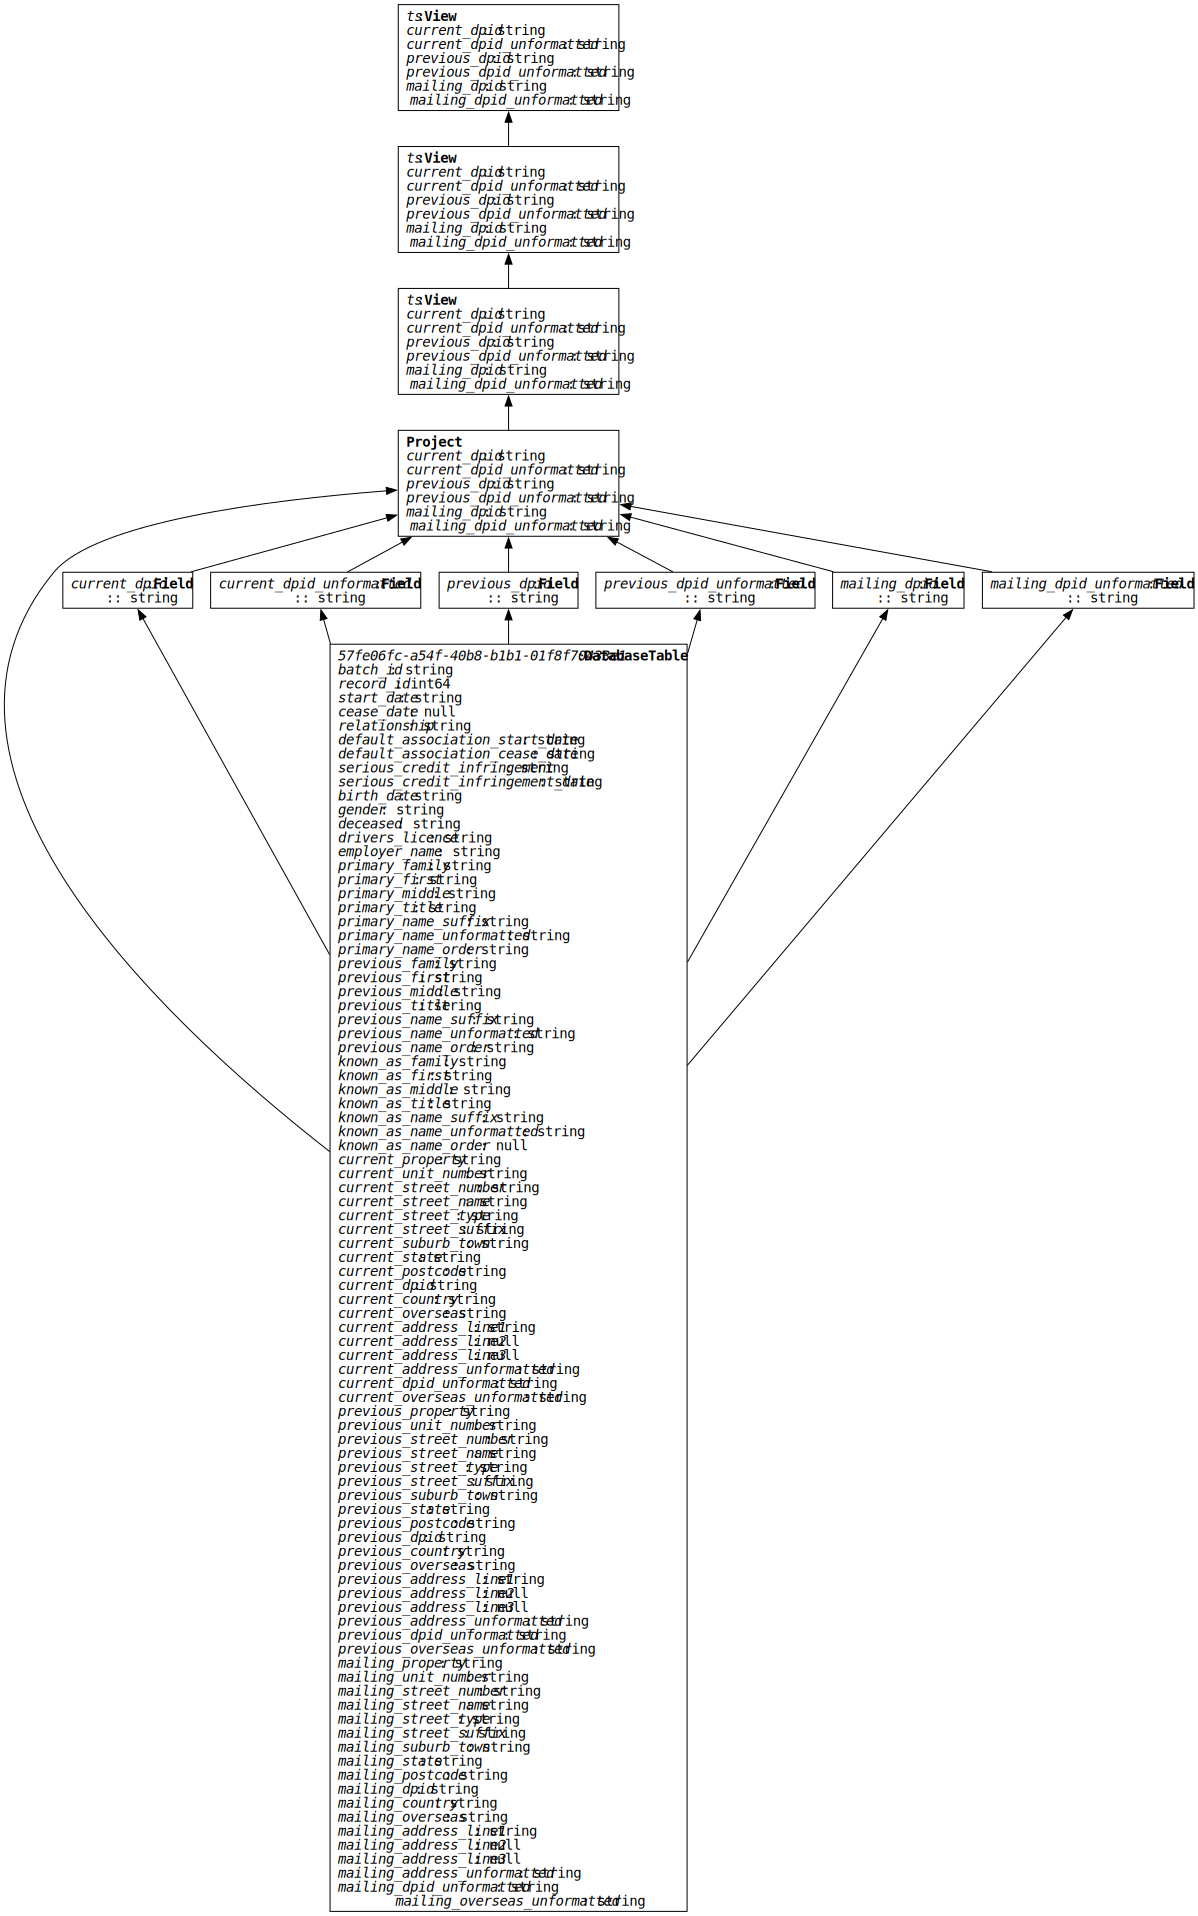

In [7]:
t2.has_name()
t2 = t2.alias("ts")
t2.get_name()

to_graph(t2)


In [ ]:
# expr = sum(_.record_id)

# t.mutate(expr).to_polars()

ibis.window()

mutate_exprs = {
    "new_col":  _.record_id + 1,
    "new_col2": _.record_id + 2
}


t2 = t.mutate(**mutate_exprs).to_polars() 
# type(t2)

objt2 = IbisDataFrame(df=t2)
type(objt2.materialise())


In [ ]:

# b = obj_pd_pq.sql("select record_id from '{_}'")
# b.get_ibis_table()
# print(b.df)

a = (obj_pd_pq
    # .get_ibis_table()
    .select("record_id")
    .sql("select record_id from '{_}'")
)

b = ( a.head(3)
    .head(2)
    # .left_join(obj_pd_pq, "record_id")
).sql("select sum(record_id) as max_record_id from '{_}'")#.get_ibis_table().compile()

# a = None
# a.df.explain(optimized=True)
print(type(b.df))
# a.get_ibis_table().execute()
# b.ibis_backend.list_tables()

In [ ]:
obj_pd_pq.get_ibis_table().execute()
print(obj_pd_pq.ibis_backend.list_tables())
# obj_pd_pq = None

obj_pd_pq.get_lineage()
# b.get_lineage()# obj_pd_pq = None
# a.



In [ ]:
obj_pd_pq = None
a = None
b = None
c = None


obj_pd_pq.ibis_backend.table('2960bf68-3322-4d39-9426-8782876f2ff7').execute()

# obj_pd2

In [ ]:
obj_pd: BaseDataFrame = DataFrameFactory.create_pandas_dataframe_object(df=df)
obj_pd2: BaseDataFrame = DataFrameFactory.create_polars_dataframe_object(df=df2)
obj_pd3: IbisDataFrame = DataFrameFactory.create_ibis_dataframe_object(df=obj_pd_pq.df.collect())




# obj_pd3.select("record_id").collect()

# obj_pd.get_ibis_table()
# obj_pd2.get_ibis_table()
# # obj_pd3.get_ibis_table()

# obj_pd4 = obj_pd2.head(n=1)
# obj_pd4.get_ibis_table()

# # expr_select = ["three", "one"]
# # expr_order_by = ["three", ibis.desc(expr="one")]

# obj_pd3.get_ibis_table().select(expr_select).order_by(expr_order_by).execute()

# # obj_pd3.get_ibis_table().get_name()

# obj_pd5 = obj_pd2.sql(query=f"SELECT 'a' as x, count(*) from '{obj_pd2.get_ibis_tablename()}'")
# obj_pd5.materialise()

# obj_pd4.get_ibis_table().get_name()


# backend = ibis.get_backend()
# backend.create_table("table", obj_pd3.get_ibis_table())
# ibis.show_sql(obj_pd3.get_ibis_table().one.count())

# ibis.to_sql(obj_pd3.get_ibis_table().count())

In [ ]:
obj_pd = obj_pd.head(1)



In [ ]:
obj_pd.collect()

In [ ]:
(obj_pd3
    .get_ibis_table()
    .select(["two", "three"])
    .distinct()
    .execute()
)


In [ ]:
df_j = obj_pd2.left_join(right=obj_pd, predicates="one")

x = DataFrameFactory.create_polars_dataframe_object(df_j.materialise())
x.df
expr_select = ["three", "one"]
expr_order_by = ["three", ibis.desc(expr="one")]

x.select(expr_select).select("one").left_join(obj_pd, ["one"]).sql(f"select * from '{{_}}'").materialise()



In [ ]:
y = "hello {name}"

y.format(name="world")

In [ ]:
con1 = ibis.pandas.connect({"t": df})
con2 = ibis.pandas.connect({"t": df2})

In [ ]:
con1.table("t").count().execute()

In [ ]:
con2.table("t").count().execute()

In [ ]:
pldf = DataFrameUtils.cast_dataframe_to_polars(df)
pddf = DataFrameFactory.create_polars_dataframe_object(df=pldf)
pddf

In [ ]:
t = pddf.get_ibis_table()

In [ ]:
x = t.head(2).filter()
type(x)

In [ ]:
#filter
from ibis import _
from ibis.common.deferred import Deferred

def build_expr(column: str, value: str):

    expr: Deferred = _[column] == value

    print(type(expr))
    return expr

expr = build_expr("one", "b")

t.filter(expr).execute()

In [ ]:
fields = ["one", "two"]

t.select(fields)
type(t)

In [ ]:
ibis.set_backend("polars")
x = t.filter(expr).limit(1)
x